In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set directory to Phase 1 folder
%cd /content/drive/MyDrive/AIKONIC-AI/PHASE_01

import config
import preprocessing_utils as pu
import matplotlib.pyplot as plt

/content/drive/MyDrive/AIKONIC-AI/PHASE_01


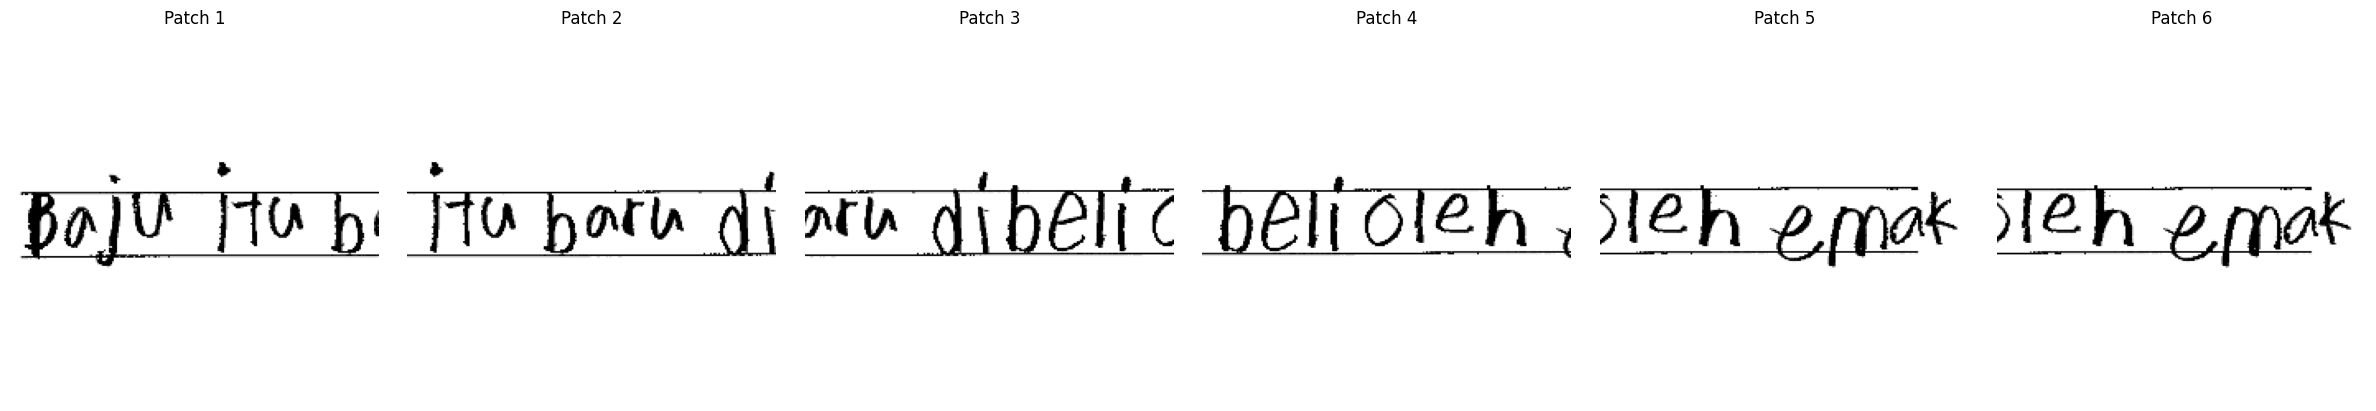

In [ ]:
# Define a raw sample to test before running the full pipeline
sample_image = str(config.RAW_DIR / "PD" / "PD (1).jpg")

patches = pu.standardize_and_patch(sample_image, target_size=224)

num_patches = len(patches)
fig, axes = plt.subplots(1, num_patches, figsize=(4 * num_patches, 4))

if num_patches == 1:
    axes = [axes]

for i, patch in enumerate(patches):
    axes[i].imshow(patch, cmap='gray')
    axes[i].set_title(f"Patch {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# This will standardize, augment, and generate the CSVs for Phase 2
pu.build_dataset_and_manifests()

✓ Spot-check grid saved to: /content/drive/MyDrive/AIKONIC-AI/data/processed/manual_spot_check_grid.png


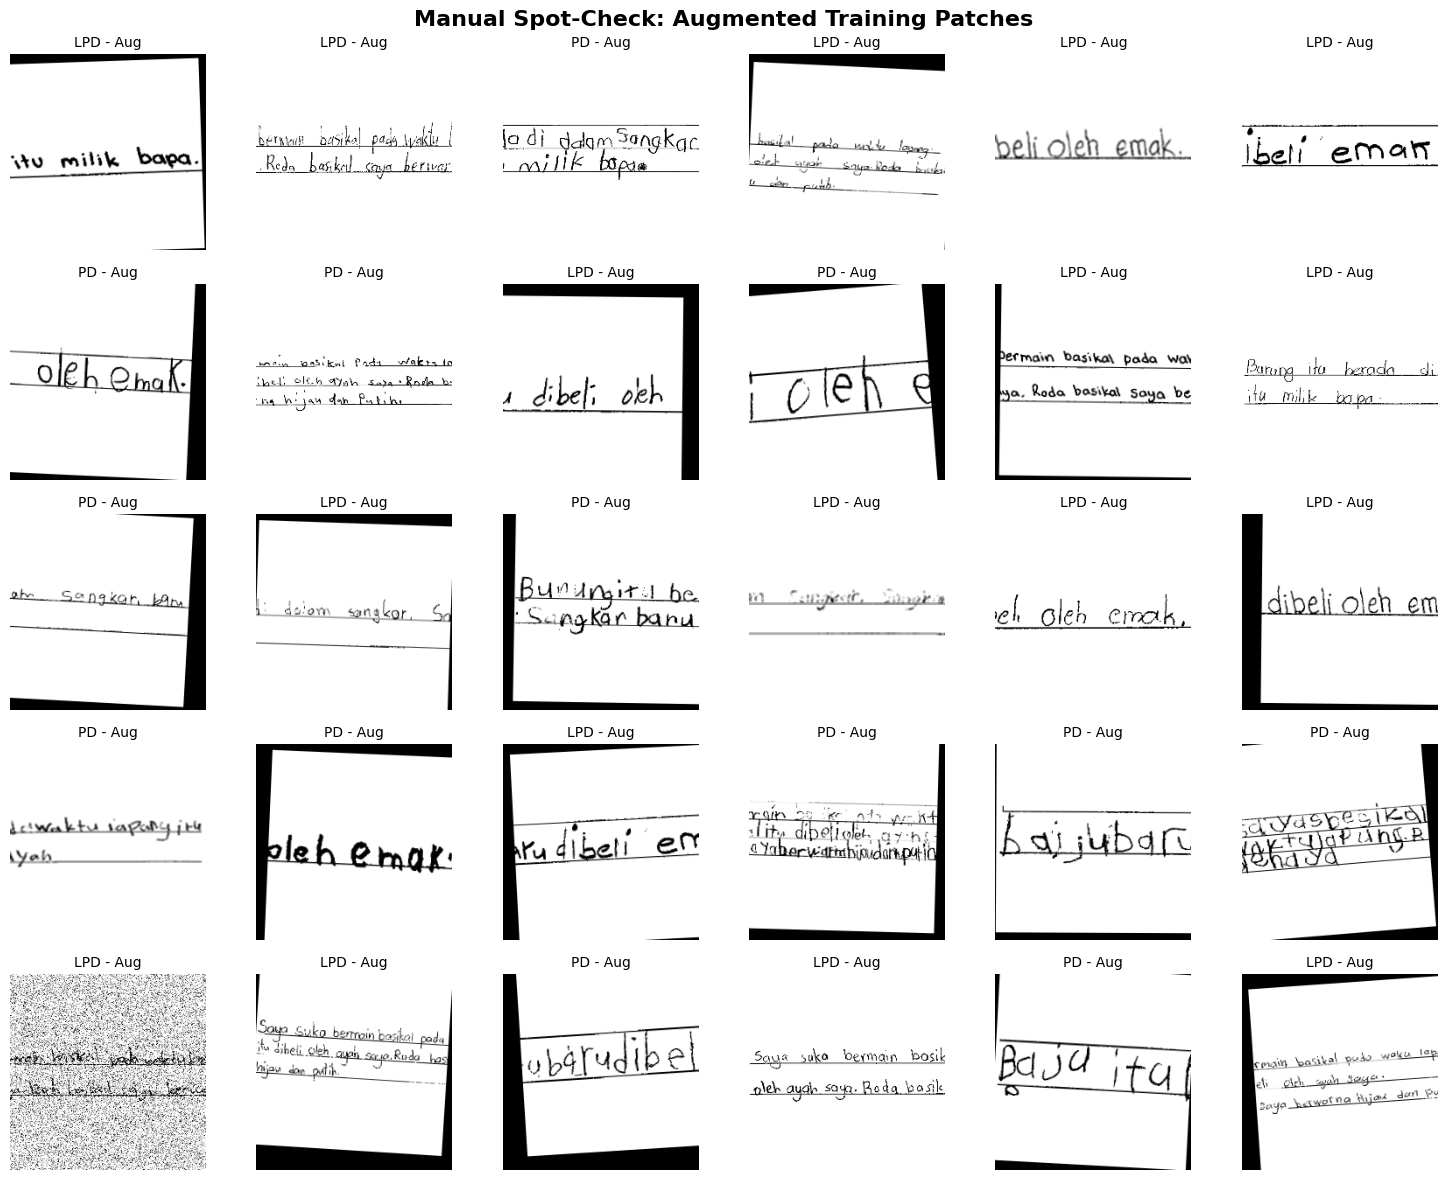

In [ ]:
# Generate 30-Image Spot-Check Grid for Documentation
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import config

def generate_spot_check_grid():
    # 1. Load the training manifest
    df = pd.read_csv(config.TRAIN_MANIFEST)

    # 2. Isolate only the augmented patches
    aug_df = df[df['augmented'] == True]

    # 3. Randomly sample exactly 30 images
    # (Using a random_state ensures you get the exact same 30 images if you run it again)
    sample_df = aug_df.sample(n=30, random_state=42)
    sample_paths = sample_df['image_path'].tolist()
    sample_labels = sample_df['label'].tolist()

    # 4. Create a 5x6 grid
    fig, axes = plt.subplots(5, 6, figsize=(15, 12))
    fig.suptitle("Manual Spot-Check: Augmented Training Patches", fontsize=16, fontweight='bold', y=0.98)

    for i, ax in enumerate(axes.flat):
        if i < len(sample_paths):
            # Load and display the image
            img = cv2.imread(sample_paths[i], cv2.IMREAD_GRAYSCALE)
            ax.imshow(img, cmap='gray')

            # Label as LPD (0) or PD (1) for context
            label_name = "PD" if sample_labels[i] == 1 else "LPD"
            ax.set_title(f"{label_name} - Aug", fontsize=10)

        ax.axis('off') # Hide axes for a cleaner look

    plt.tight_layout()

    # Save a high-resolution copy directly to your folder for the paper
    save_path = config.PROCESSED_DIR / "manual_spot_check_grid.png"
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Spot-check grid saved to: {save_path}")

    plt.show()

generate_spot_check_grid()